# <h1><b>Text Preprocessing </b><h1>

In [84]:
import os
print(os.getcwd())

c:\Users\richm\OneDrive\Desktop\AI Engineering\NLP


In [85]:
with open("./txt_files/bagofwords.txt", "r") as file:
    data = file.read()

print(data)

[' Most shark attacks occur about 10 feet from the beach since that is where the people are',
        'the efficiency with which he paired the socks in the drawer was quite admirable',
        'carol drank the blood as if she were a vampire',
        'giving directions that the mountains are to the west only works when you can see them',
        'the sign said there was road work ahead so he decided to speed up',
        'the gruff old man sat in the back of the bait shop grumbling to himself as he scooped out a handful of worms']


In [86]:
import ast

data = ast.literal_eval(data)
print(type(data))
print(data)


<class 'list'>
[' Most shark attacks occur about 10 feet from the beach since that is where the people are', 'the efficiency with which he paired the socks in the drawer was quite admirable', 'carol drank the blood as if she were a vampire', 'giving directions that the mountains are to the west only works when you can see them', 'the sign said there was road work ahead so he decided to speed up', 'the gruff old man sat in the back of the bait shop grumbling to himself as he scooped out a handful of worms']


In [87]:
lower_case_data = [x.strip().lower() for x in data]
for data in lower_case_data:
    print(data)

most shark attacks occur about 10 feet from the beach since that is where the people are
the efficiency with which he paired the socks in the drawer was quite admirable
carol drank the blood as if she were a vampire
giving directions that the mountains are to the west only works when you can see them
the sign said there was road work ahead so he decided to speed up
the gruff old man sat in the back of the bait shop grumbling to himself as he scooped out a handful of worms


## <h2><b> Removing stopwords </b></h2>

In [ ]:
%pip install nltk

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords as _nltk_stopwords

def stopwords(lang='english'):
	return _nltk_stopwords.words(lang)

Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\richm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [89]:
en_stopwords = stopwords('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
sentence = "it was too far to go to the shop and he did not want her to walk"
rm_stopwords = " ".join([word for word in sentence.split() if word not in en_stopwords])
print(rm_stopwords)

far go shop want walk


In [91]:
print(lower_case_data)

['most shark attacks occur about 10 feet from the beach since that is where the people are', 'the efficiency with which he paired the socks in the drawer was quite admirable', 'carol drank the blood as if she were a vampire', 'giving directions that the mountains are to the west only works when you can see them', 'the sign said there was road work ahead so he decided to speed up', 'the gruff old man sat in the back of the bait shop grumbling to himself as he scooped out a handful of worms']


In [92]:
rm_stopwords = [" ".join([word for word in sentence.split() if word not in en_stopwords]) for sentence in lower_case_data ]
rm_stopwords

['shark attacks occur 10 feet beach since people',
 'efficiency paired socks drawer quite admirable',
 'carol drank blood vampire',
 'giving directions mountains west works see',
 'sign said road work ahead decided speed',
 'gruff old man sat back bait shop grumbling scooped handful worms']

## <h2><b> Regular Expression (regex) </b></h2>

In [93]:
import re

customer_reviews = ['sam was a great help to me in the store', 
                    'the cashier was very rude to me, I think her name was eleanor', 
                    'amazing work from sadeen!', 
                    'sarah was able to help me find the items i needed quickly', 
                    'lucy is such a great addition to the team', 
                    'great service from sara she found me what i wanted'
                   ]

def get_pattern(pattern, review_lst):
    for sentence in customer_reviews:
        if(re.search(pattern, sentence)):
            review_lst.append(sentence)
    print(review_lst)

In [94]:
sarahs_review = []
find_sarah_pattern = r"sarah?" # select all words that have the sara or sarah pattern 
get_pattern(find_sarah_pattern, sarahs_review)

['sarah was able to help me find the items i needed quickly', 'great service from sara she found me what i wanted']


In [95]:
a_review = []
find_a_pattern = r"^a" # pattern that select all words startig with a
get_pattern(find_a_pattern, a_review)

['amazing work from sadeen!']


In [96]:
Y_reviews = []
find_y_pattern = r"y$" # finds words that ends with y
get_pattern(find_y_pattern, Y_reviews)

['sarah was able to help me find the items i needed quickly']


In [97]:
needwant_review = []
find_needwant_pattern = r"(need|want)ed" # this pattern finds words that have need or wants in the word sequence
get_pattern(find_needwant_pattern, needwant_review)

['sarah was able to help me find the items i needed quickly', 'great service from sara she found me what i wanted']


In [98]:
""" 
 r"[^\w\s]"
 [] = a set of characters we want to much
 ^  = not
 \w = word charaters
 \s = whitespace charaters

 Altogether mean find punctuations in a sentence
 """
no_punct_reviews = []
find_nopunct_pattern = r"[^\w\s]" 

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
C:\Users\richm\AppData\Local\Temp\ipykernel_26604\3168909396.py:2: SyntaxWarning: invalid escape sequence '\w'
  r"[^\w\s]"


In [99]:
get_pattern(pattern=find_nopunct_pattern, review_lst=no_punct_reviews)

['the cashier was very rude to me, I think her name was eleanor', 'amazing work from sadeen!']


In [100]:
review_lst = []
for review in customer_reviews:
    no_punct_string = re.sub(find_nopunct_pattern, "", review)
    review_lst.append(no_punct_string)

print(review_lst)

['sam was a great help to me in the store', 'the cashier was very rude to me I think her name was eleanor', 'amazing work from sadeen', 'sarah was able to help me find the items i needed quickly', 'lucy is such a great addition to the team', 'great service from sara she found me what i wanted']


## <h2><b> Tokenization </b></h2>

In [101]:
import nltk
nltk.download('punkt_tab') # 'punkt_tab' a table used to figure out where sentences begin and end
from nltk.tokenize import word_tokenize, sent_tokenize

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\richm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [102]:
sentence = "Her cat's name is luna. Her dog's name is max".lower()

In [103]:
sent_tokenize(sentence)

["her cat's name is luna.", "her dog's name is max"]

In [104]:
word_tokenize(sentence)

['her',
 'cat',
 "'s",
 'name',
 'is',
 'luna',
 '.',
 'her',
 'dog',
 "'s",
 'name',
 'is',
 'max']

## <h2><b> Stemming and Lemmatization </b></h2>

### <h3><b><i> Stemming </i> </b></h3>

In [105]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()
connect_tokens = ['connecting', 'connected', 'connectivity', 'connect', 'connects', 'studies']
learn_tokens = ['learned', "learning", "learn", "learner", "learn", "learners"]
likes_token = ["likes", "better", "worse"]

In [106]:
for t in connect_tokens:
    print(f"{t} : {ps.stem(t)}")

connecting : connect
connected : connect
connectivity : connect
connect : connect
connects : connect
studies : studi


In [107]:
for t in learn_tokens:
    print(f"{t} : {ps.stem(t)}")

learned : learn
learning : learn
learn : learn
learner : learner
learn : learn
learners : learner


In [108]:
for t in likes_token:
    print(f"{t} : {ps.stem(t)}")

likes : like
better : better
worse : wors


### <h3><b><i> Lemmatization </i> </b></h3>

In [109]:
nltk.download("wordnet")
from nltk import WordNetLemmatizer
lem = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\richm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [110]:
for t in connect_tokens:
    print(f"{t} : {lem.lemmatize(t)}")

connecting : connecting
connected : connected
connectivity : connectivity
connect : connect
connects : connects
studies : study


In [111]:
for t in likes_token:
    print(f"{t} : {lem.lemmatize(t)}")

likes : like
better : better
worse : worse


In [112]:
for t in learn_tokens:
    print(f"{t} : {lem.lemmatize(t)}")

learned : learned
learning : learning
learn : learn
learner : learner
learn : learn
learners : learner


## <h2><b> N-grams </b></h2>

N-grams help us analyze the relationship between neighboring words <br>
N-grams = a sequence of N tokens

(eg. "I love NLP") <br>
N = 1 : unigram <==> tokens("i", "love", "NLP")<br>
N = 2 : bigram <==> tokens("I love", "love NLP")<br>
N = 3 : trigram <==> tokens("I love NLP")<br>

In [113]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt

In [114]:
tokens = ['the', 'rise', 'of', 'artificial', 'intelligence', 'has', 'led', 'to', 'significant', 'advancements', 'in', 'natural', 'language', 'processing', 'computer', 'vision', 'and', 'other', 'fields', 'machine', 'learning', 'algorithms', 'are', 'becoming', 'more', 'sophisticated', 'enabling', 'computers', 'to', 'perform', 'complex', 'tasks', 'that', 'were', 'once', 'thought', 'to', 'be', 'the', 'exclusive', 'domain', 'of', 'humans', 'with', 'the', 'advent', 'of', 'deep', 'learning', 'neural', 'networks', 'have', 'become', 'even', 'more', 'powerful', 'capable', 'of', 'processing', 'vast', 'amounts', 'of', 'data', 'and', 'learning', 'from', 'it', 'in', 'ways', 'that', 'were', 'not', 'possible', 'before', 'as', 'a', 'result', 'ai', 'is', 'increasingly', 'being', 'used', 'in', 'a', 'wide', 'range', 'of', 'industries', 'from', 'healthcare', 'to', 'finance', 'to', 'transportation', 'and', 'its', 'impact', 'is', 'only', 'set', 'to', 'grow', 'in', 'the', 'years', 'to', 'come']
tokens

['the',
 'rise',
 'of',
 'artificial',
 'intelligence',
 'has',
 'led',
 'to',
 'significant',
 'advancements',
 'in',
 'natural',
 'language',
 'processing',
 'computer',
 'vision',
 'and',
 'other',
 'fields',
 'machine',
 'learning',
 'algorithms',
 'are',
 'becoming',
 'more',
 'sophisticated',
 'enabling',
 'computers',
 'to',
 'perform',
 'complex',
 'tasks',
 'that',
 'were',
 'once',
 'thought',
 'to',
 'be',
 'the',
 'exclusive',
 'domain',
 'of',
 'humans',
 'with',
 'the',
 'advent',
 'of',
 'deep',
 'learning',
 'neural',
 'networks',
 'have',
 'become',
 'even',
 'more',
 'powerful',
 'capable',
 'of',
 'processing',
 'vast',
 'amounts',
 'of',
 'data',
 'and',
 'learning',
 'from',
 'it',
 'in',
 'ways',
 'that',
 'were',
 'not',
 'possible',
 'before',
 'as',
 'a',
 'result',
 'ai',
 'is',
 'increasingly',
 'being',
 'used',
 'in',
 'a',
 'wide',
 'range',
 'of',
 'industries',
 'from',
 'healthcare',
 'to',
 'finance',
 'to',
 'transportation',
 'and',
 'its',
 'impact'

### Unigrams (N=1)

In [120]:
unigram = (pd.Series(nltk.ngrams(tokens, 1))).value_counts()
unigram

(to,)       7
(of,)       6
(the,)      4
(in,)       4
(and,)      3
           ..
(only,)     1
(set,)      1
(grow,)     1
(years,)    1
(come,)     1
Name: count, Length: 79, dtype: int64

Text(0.5, 1.0, '10 Most requently occuring unigrams')

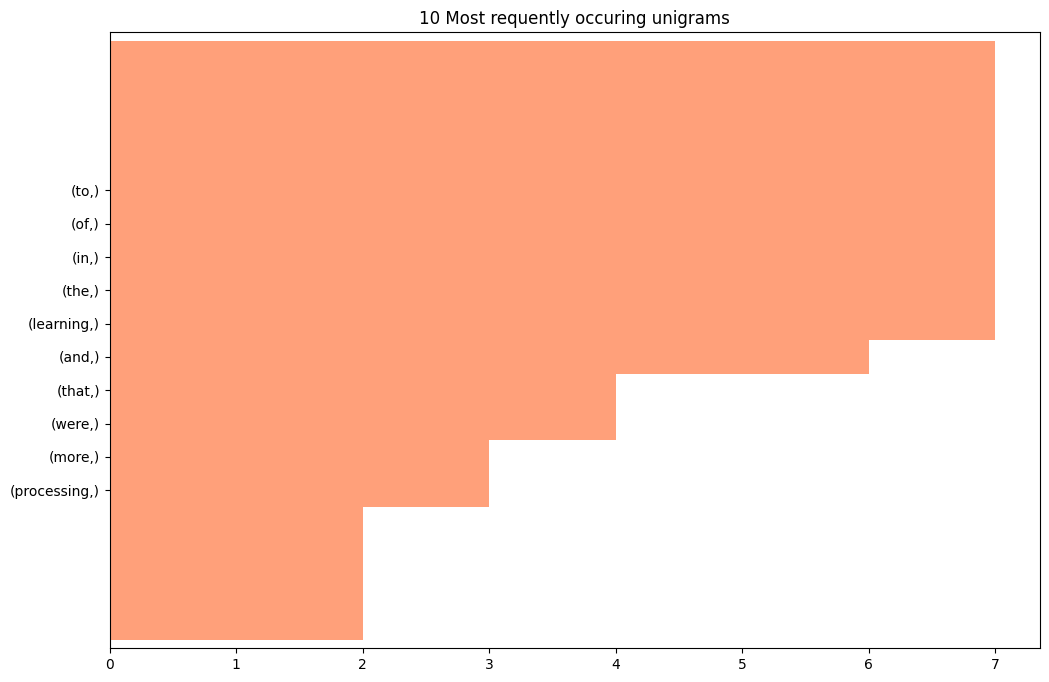

In [128]:
unigram[:10].sort_values().plot.barh(color="lightsalmon", width=9, figsize=(12,8))
plt.title("10 Most requently occuring unigrams")

### Bigrams (N=2)

In [123]:
bigrams = (pd.Series(nltk.ngrams(tokens, 2)).value_counts())
bigrams

(that, were)                  2
(the, rise)                   1
(rise, of)                    1
(of, artificial)              1
(artificial, intelligence)    1
                             ..
(grow, in)                    1
(in, the)                     1
(the, years)                  1
(years, to)                   1
(to, come)                    1
Name: count, Length: 105, dtype: int64

Text(0.5, 1.0, '10 Most requently occuring unigrams')

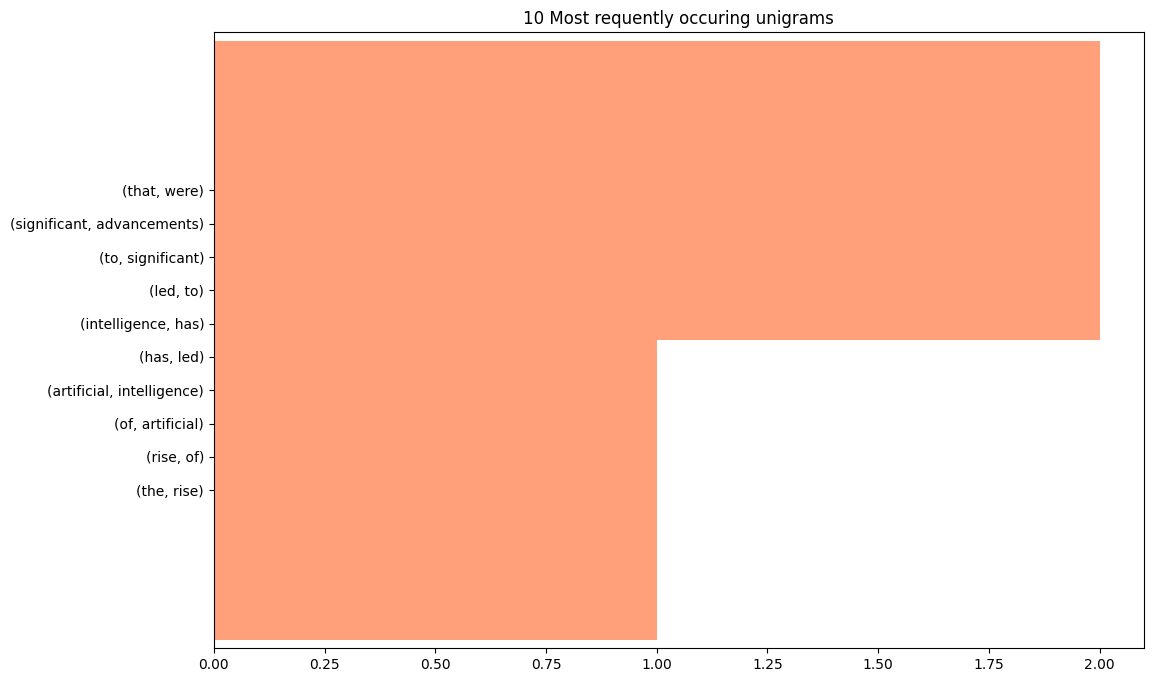

In [124]:
bigrams[:10].sort_values().plot.barh(color="lightsalmon", width=9, figsize=(12,8))
plt.title("10 Most requently occuring unigrams")

### Trigrams (N=3)

In [125]:
trigrams = (pd.Series(nltk.ngrams(tokens, 3)).value_counts())
trigrams

(the, rise, of)                    1
(rise, of, artificial)             1
(of, artificial, intelligence)     1
(artificial, intelligence, has)    1
(intelligence, has, led)           1
                                  ..
(to, grow, in)                     1
(grow, in, the)                    1
(in, the, years)                   1
(the, years, to)                   1
(years, to, come)                  1
Name: count, Length: 105, dtype: int64

Text(0.5, 1.0, '10 Most requently occuring unigrams')

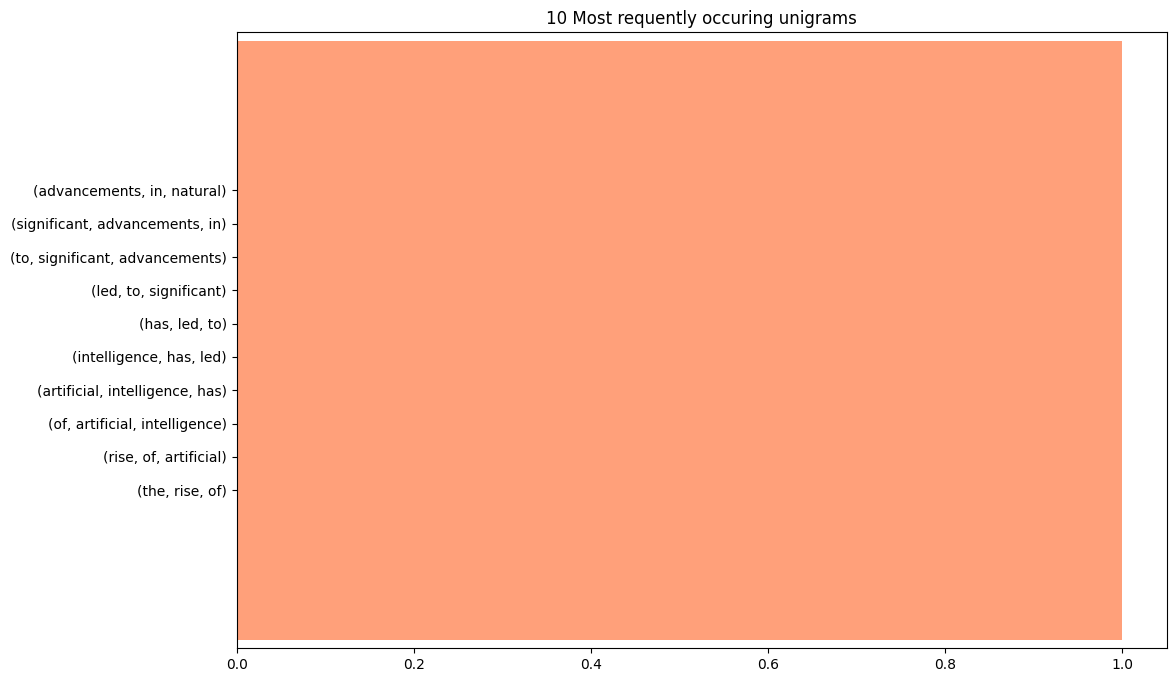

In [126]:
trigrams[:10].sort_values().plot.barh(color="lightsalmon", width=9, figsize=(12,8))
plt.title("10 Most requently occuring unigrams")

NB: Any number (N) that is greater than 3 (N>3) is referenced as N-grams